# **A Deep Dive into Supplements Adverse Events**

#### **By Ali Albinfalah**

---------------------------------------
## **1. Data Info**

In [2]:
import pandas as pd

df= pd.read_csv(r"C:\Users\alial\OneDrive\Desktop\GA\capstone\HFCS-Quarterly-20250930--CSV_PRODUCT-BASED.csv")

In [3]:
df.shape # The dataset contains 231897 rows and 12 columns (rows, columns)

(231897, 12)

In [4]:
df.columns # Displaying the column names

Index(['DATE_FDA_FIRST_RECEIVED_REPORT', 'REPORT_ID', 'DATE_EVENT',
       'PRODUCT_TYPE', 'PRODUCT', 'PRODUCT_CODE', 'DESCRIPTION', 'PATIENT_AGE',
       'AGE_UNITS', 'SEX', 'CASE_MEDDRA_PREFERRED_TERMS', 'CASE_OUTCOME'],
      dtype='str')

In [5]:
df.info() # Checking the data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 231897 entries, 0 to 231896
Data columns (total 12 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   DATE_FDA_FIRST_RECEIVED_REPORT  231897 non-null  str    
 1   REPORT_ID                       231897 non-null  str    
 2   DATE_EVENT                      159547 non-null  str    
 3   PRODUCT_TYPE                    231897 non-null  str    
 4   PRODUCT                         231896 non-null  str    
 5   PRODUCT_CODE                    231897 non-null  str    
 6   DESCRIPTION                     231897 non-null  str    
 7   PATIENT_AGE                     155665 non-null  float64
 8   AGE_UNITS                       155665 non-null  str    
 9   SEX                             219108 non-null  str    
 10  CASE_MEDDRA_PREFERRED_TERMS     231897 non-null  str    
 11  CASE_OUTCOME                    231897 non-null  str    
dtypes: float64(1), str(11)
memo

In [6]:
df.sample(5) # Displaying 5 random rows to help us understand the structure

,DATE_FDA_FIRST_RECEIVED_REPORT,REPORT_ID,DATE_EVENT,PRODUCT_TYPE,PRODUCT,PRODUCT_CODE,DESCRIPTION,PATIENT_AGE,AGE_UNITS,SEX,CASE_MEDDRA_PREFERRED_TERMS,CASE_OUTCOME
158049,2/16/2016,194454,NaN,SUSPECT,EXEMPTION 4,53,Cosmetics,39.0,year(s),Female,OVARIAN CANCER,"Other Serious or Important Medical Event, Visi..."
101352,2/12/2019,2019-CFS-001427,2/1/2014,SUSPECT,EXEMPTION 4,53,Cosmetics,NaN,NaN,Female,Ovarian cancer,Other Serious or Important Medical Event
35755,5/23/2022,2022-CFS-008349,4/1/2022,SUSPECT,JIF PEANUT BUTTER,23,Nuts/Edible Seed,26.0,year(s),Female,"Abdominal pain upper, Functional gastrointesti...",Other Serious or Important Medical Event
72133,1/6/2021,2021-CFS-000795,1/1/2010,SUSPECT,EXEMPTION 4,53,Cosmetics,25.0,year(s),Female,"Death, Injury",Death
190259,1/14/2013,161121,1/11/2013,SUSPECT,LACTAID FAST ACT,54,Vit/Min/Prot/Unconv Diet(Human/Animal),57.0,year(s),Female,"DIARRHOEA, NAUSEA, VOMITING",Other Serious or Important Medical Event


---------------------------------------
## **2. Data Cleaning**

### 2.1 Removing Concomitant Products

The dataset contains two product type classifications:
- **SUSPECT (84.68%, 196,370 rows)** — Products the reporter believed caused the adverse event
- **CONCOMITANT (15.32%, 35,527 rows)** — Other products the patient was taking at the same time

**CONCOMITANT** rows represent products taken alongside the suspected product but not believed to have caused the adverse event. Including them would conflate background context with causal association. They also contain significantly higher null rates across key analytical columns, so their rows were removed to keep the analysis focused on products directly associated with harm.

In [7]:
# Displaying the count of rows and the percentages of each of the product type categories

print(df["PRODUCT_TYPE"].value_counts())
print("-----------------------------")
print(df["PRODUCT_TYPE"].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

PRODUCT_TYPE
SUSPECT        196370
CONCOMITANT     35527
Name: count, dtype: int64
-----------------------------
PRODUCT_TYPE
SUSPECT        84.68%
CONCOMITANT    15.32%
Name: proportion, dtype: str


In [8]:
df = df[df["PRODUCT_TYPE"] == "SUSPECT"]

print("Total rows after removing CONCOMITANT rows :", len(df))

Total rows after removing CONCOMITANT rows : 196370


In [9]:
# Now we will drop the PRODUCT_TYPE column since it will only contain SUSPECT products

df = df.drop("PRODUCT_TYPE", axis=1)

### 2.2 Removing Cosmetic Products

In [10]:
# Let's look at top 10 most common product categories

df["DESCRIPTION"].value_counts().head(10)

DESCRIPTION
Cosmetics                                       82868
Vit/Min/Prot/Unconv Diet(Human/Animal)          62591
Nuts/Edible Seed                                 5720
Vegetables/Vegetable Products                    4966
Soft Drink/Water                                 3879
Bakery Prod/Dough/Mix/Icing                      3838
Fruit/Fruit Prod                                 3606
Fishery/Seafood Prod                             3283
Cereal Prep/Breakfast Food                       2554
Dietary Conventional Foods/Meal Replacements     2236
Name: count, dtype: int64

In [11]:
# We will exclude cosmetic products despite being the largest category due to the focus of our analysis only being on food and supplements

df= df[df["DESCRIPTION"] != "Cosmetics"]

### 2.3 Handling Duplicates

In [12]:
# Checking how many duplicated rows are there

df.duplicated().sum()

np.int64(421)

In [13]:
# We will drop the duplicated rows

df= df.drop_duplicates()

In [14]:
# Checking how many duplicated rows are there in the REPORT_ID column

df['REPORT_ID'].duplicated().sum()

np.int64(16664)

There are 16664 duplicates in ``REPORT_ID``, and thats normal because one report can involve multiple products. So each row gets its own row but shares the same report id.

For example, a person takes 3 supplements and reports an adverse event, that's one report id with 3 rows, one per product.

### 2.4 Renaming Columns

In [41]:
# Renaming some of the columns for clarity

df = df.rename(columns={
    "DATE_FDA_FIRST_RECEIVED_REPORT":"DATE_REPORTED",
    "DESCRIPTION":"PRODUCT_CATEGORY",
    "PATIENT_AGE":"AGE",
    "CASE_MEDDRA_PREFERRED_TERMS":"SYMPTOMS"
})

### 2.5 Removing Extra Spaces 

In [16]:
# Since strip only works on string columns...
# I will use .dtypes to check which of the columns are in string format.

df.dtypes

DATE_REPORTED           str
REPORT_ID               str
DATE_EVENT              str
PRODUCT                 str
PRODUCT_CODE            str
PRODUCT_CATEGORY        str
AGE                 float64
AGE_UNITS               str
SEX                     str
SYMPTOMS                str
CASE_OUTCOME            str
dtype: object

In [17]:
# Striping whitespace from all string columns

string_cols = ["DATE_REPORTED", "REPORT_ID", "DATE_EVENT", "PRODUCT",
               "PRODUCT_CODE", "PRODUCT_CATEGORY", "AGE_UNITS",
               "SEX", "SYMPTOMS", "CASE_OUTCOME"
              ]
    
for col in string_cols:
    df[col] = df[col].str.strip()

### 2.6 Changing Column Types

In [18]:
# Converting the date columns to datetime
df["DATE_REPORTED"] = pd.to_datetime(df["DATE_REPORTED"])
df["DATE_EVENT"] = pd.to_datetime(df["DATE_EVENT"])

# Converting string columns to category columns
df["PRODUCT_CATEGORY"] = df["PRODUCT_CATEGORY"].astype("category")
df["SEX"] = df["SEX"].astype("category")

# Confirming the new datatypes
df.dtypes

DATE_REPORTED       datetime64[us]
REPORT_ID                      str
DATE_EVENT          datetime64[us]
PRODUCT                        str
PRODUCT_CODE                   str
PRODUCT_CATEGORY          category
AGE                        float64
AGE_UNITS                      str
SEX                       category
SYMPTOMS                       str
CASE_OUTCOME                   str
dtype: object

### 2.7 Handling Nulls

In [19]:
print(df.isnull().sum()) # checking the count of nulls in each columns
print("------------------------------")
print((df.isnull().sum() / len(df) * 100).round(2).astype(str) + '%') # Checking the percentages of nulls in each columns

DATE_REPORTED           0
REPORT_ID               0
DATE_EVENT          42773
PRODUCT                 0
PRODUCT_CODE            0
PRODUCT_CATEGORY        0
AGE                 44622
AGE_UNITS           44622
SEX                 10162
SYMPTOMS                0
CASE_OUTCOME            0
dtype: int64
------------------------------
DATE_REPORTED         0.0%
REPORT_ID             0.0%
DATE_EVENT          37.83%
PRODUCT               0.0%
PRODUCT_CODE          0.0%
PRODUCT_CATEGORY      0.0%
AGE                 39.46%
AGE_UNITS           39.46%
SEX                  8.99%
SYMPTOMS              0.0%
CASE_OUTCOME          0.0%
dtype: str


Four columns contain null values, all of them are optional fields in the FDA adverse events reporting form.

| Column | Null Count | Null % | Action |
|---|---|---|---|
| ``DATE_EVENT`` | 42,773 | 37.83% | Nulls will be left as they are because it's a date column and shouldn't contain text placeholders |
| ``AGE`` | 44,622 | 39.46% | Will be handled later during age group bucketing |
| ``AGE_UNITS`` | 44,622 | 39.46% | Will be handled later during age group bucketing |
| ``SEX`` | 10,162 | 8.99% | Will be filled with "Not Reported" |

In [20]:
# Filling missing SEX values with 'Not Reported'
df["SEX"] = df["SEX"].cat.add_categories("Not Reported").fillna("Not Reported")

# Confirming no remaining nulls in SEX
df.isnull().sum()

DATE_REPORTED           0
REPORT_ID               0
DATE_EVENT          42773
PRODUCT                 0
PRODUCT_CODE            0
PRODUCT_CATEGORY        0
AGE                 44622
AGE_UNITS           44622
SEX                     0
SYMPTOMS                0
CASE_OUTCOME            0
dtype: int64

### 2.8 Age Standardization and Grouping

In [21]:
# Replacing unrealistic age values (ones above 105) with NaN

df.loc[(df["AGE"] > 105) & (df["AGE_UNITS"] == "year(s)"), "AGE"] = None

In [22]:
# Creating a new column called AGE_YEARS as a copy of AGE

df["AGE_YEARS"] = df["AGE"]

In [23]:
# Converting months to years
df.loc[df["AGE_UNITS"] == "month(s)", "AGE_YEARS"] = (df["AGE"] / 12).round(2)

# Converting days to years
df.loc[df["AGE_UNITS"] == "day(s)", "AGE_YEARS"] = (df["AGE"] / 365).round(2)

# Converting weeks to years
df.loc[df["AGE_UNITS"] == "week(s)", "AGE_YEARS"] = (df["AGE"] / 52).round(2)

# Converting decades to years
df.loc[df["AGE_UNITS"] == "decade(s)", "AGE_YEARS"] = (df["AGE"] * 10).round(2)

In [24]:
# Defining a function to categorize age into groups
def categorize_age(age):
    
    if pd.isnull(age):
        return "Not Reported" # If age is missing, label as Not Reported
    elif age <= 17:
        return "Minors" # (Under 18)
    elif age <= 34:
        return "Young Adults" # (18-34)
    elif age <= 54:
        return "Middle Aged Adults" # (35-54)
    elif age <= 64:
        return "Older Adults" # (55-64)
    else:
        return "Seniors" # (65+)

# Applying the function to AGE_YEARS and storing the result in a new column AGE_GROUP
df["AGE_GROUP"] = df["AGE_YEARS"].apply(categorize_age)

In [25]:
# Converting the AGE_GROUP column type to category

df['AGE_GROUP'] = df['AGE_GROUP'].astype('category')

### 2.9 Outcome Categorization

In [26]:
df["CASE_OUTCOME"].nunique()

386

The CASE_OUTCOME column contains 386 unique combinations of outcomes since reporters can select multiple outcomes per case. A binary column (1 = present, 0 = absent) will be created for each meaningful outcome category based on keyword matching.

In [27]:
# Creating a binary column for outcome categories
# 1 = outcome was reported, 0 = outcome was not reported

df["DEATH"] = df["CASE_OUTCOME"].str.contains("Death", na=False).astype(int)

df["LIFE_THREATENING"] = df["CASE_OUTCOME"].str.contains("Life Threatening", na=False).astype(int)

df["HOSPITALIZATION"] = df["CASE_OUTCOME"].str.contains("Hospitalization", na=False).astype(int)

df["DISABILITY"] = df["CASE_OUTCOME"].str.contains("Disability", na=False).astype(int)

df["CONGENITAL_ANOMALY"] = df["CASE_OUTCOME"].str.contains("Congenital Anomaly", na=False).astype(int)

df["ALLERGIC_REACTION"] = df["CASE_OUTCOME"].str.contains("Allergic Reaction", na=False).astype(int)

df["INJURY"] = df["CASE_OUTCOME"].str.contains("Injury", na=False).astype(int)

### 2.10 Dropping Unnecessary Columns

In [28]:
# Checking all the columns

df.columns

Index(['DATE_REPORTED', 'REPORT_ID', 'DATE_EVENT', 'PRODUCT', 'PRODUCT_CODE',
       'PRODUCT_CATEGORY', 'AGE', 'AGE_UNITS', 'SEX', 'SYMPTOMS',
       'CASE_OUTCOME', 'AGE_YEARS', 'AGE_GROUP', 'DEATH', 'LIFE_THREATENING',
       'HOSPITALIZATION', 'DISABILITY', 'CONGENITAL_ANOMALY',
       'ALLERGIC_REACTION', 'INJURY'],
      dtype='str')

The table below shows which columns will be dropped and why

| Column | Reason for Dropping |
|---|---|
| ``AGE`` | Replaced by ``AGE_YEARS`` and ``AGE_GROUP`` |
| ``AGE_UNITS`` |  Will No longer be needed since all ages were converted to years |
| ``PRODUCT_CODE`` | The FDA industry code associated with the type of product reported.  Will not be used in analysis |
| ``DATE_EVENT`` | Has nulls and the dates may not be accurate. ``DATE_REPORTED`` will used for trend analysis instead |

In [29]:
# Dropping unnecessary columns

df = df.drop(columns=["AGE", "AGE_UNITS", "PRODUCT_CODE", "DATE_EVENT"])

---------------------------------------
## **3. Word Cloud Analysis**

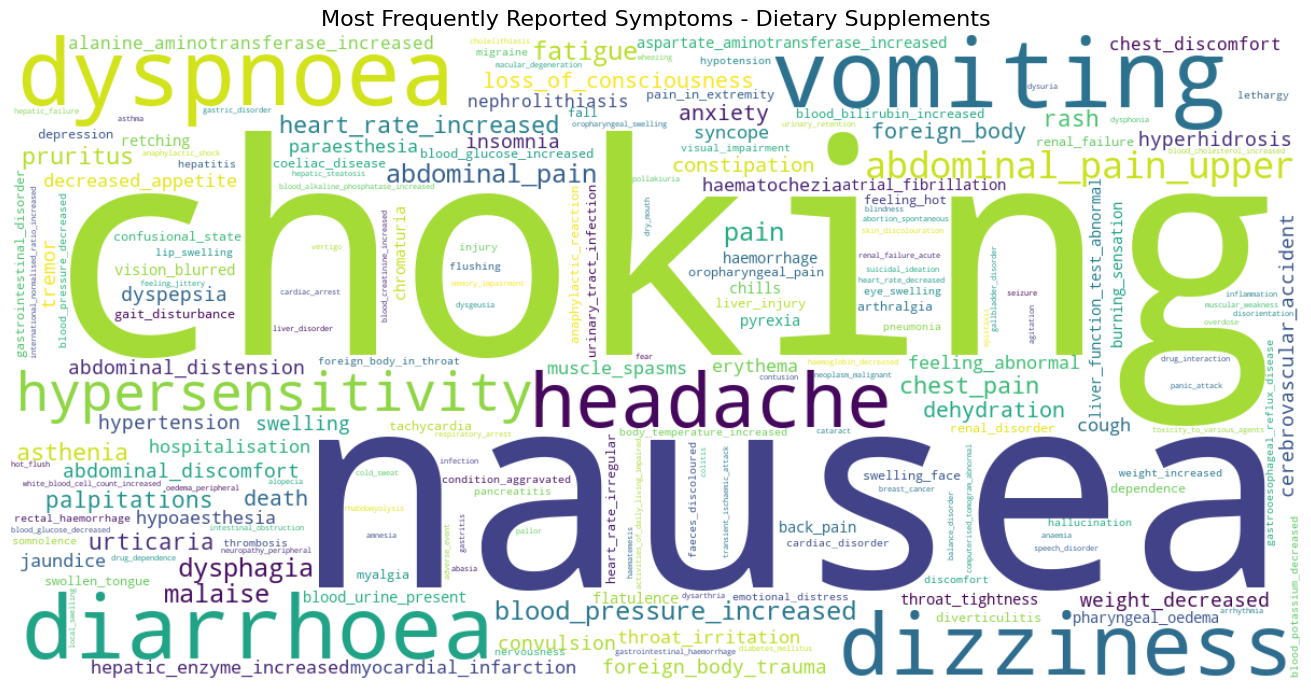

In [47]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter to supplements only
supp_symptoms = df[df['PRODUCT_CATEGORY'] == 'Vit/Min/Prot/Unconv Diet(Human/Animal)']['SYMPTOMS']

# Split, lowercase and strip all symptoms into a single list
all_symptoms = (supp_symptoms
                .str.lower()
                .str.split(',')
                .explode()
                .str.strip())

# Replace spaces within each symptom with underscores
all_symptoms = all_symptoms.str.replace(' ', '_')

# Join all symptoms into a single string for the word cloud
symptoms_text = ' '.join(all_symptoms)

# Generate word cloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    collocations=False
).generate(symptoms_text)

# Display
plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequently Reported Symptoms - Dietary Supplements', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=300, bbox_inches='tight', facecolor='#0a2342')
plt.show()

---------------------------------------
## **4. Top 10 Most Common Supplement Products**

In [32]:
# Filter to supplements only
supp = df[df['PRODUCT_CATEGORY'] == 'Vit/Min/Prot/Unconv Diet(Human/Animal)']

# Top 10 most reported products
top_products = supp['PRODUCT'].value_counts().head(10)
print(top_products.to_string())

PRODUCT
SUPER BETA PROSTATE                                                 1103
PRESERVISION AREDS 2                                                 807
EXEMPTION 4                                                          710
CENTRUM SILVER WOMEN'S 50+ (MULTIMINERALS, MULTIVITAMINS) TABLET     618
PRESERVISION AREDS 2 FORMULA SOFT GELS                               431
CITRACAL MAXIMUM                                                     417
KRATOM                                                               401
HYDROXYCUT REGULAR RAPID RELEASE CAPLETS                             327
CITRACAL PETITES                                                     243
SUPER BETA PROSTATE P3 ADVANCED                                      239


---------------------------------------
## **5. Extracting the File**

In [39]:
df.to_csv('AdverseEvents_Cleaned.csv', index=False)